# **Stage 1**

# **Analyzing Coffee Shop Sales**
---
## Question:

## **Which product drives the most revenue, and how do sales trends vary by day of the week?**


# **Stage 2**: What Does the Data Look Like?
---

### The first thing that I have done is to import the libraries that I need. Each of these libraries plays a specific role in helping me complete different parts of the project:

In [3]:
import pandas as pd          # To load and manipulate tabular data
import sqlite3               # To connect to the SQLite database where the data is stored
import matplotlib.pyplot as plt  # To create basic visualizations like bar and line plots
import seaborn as sns        # To create clean and attractive statistical graphics

## 1. Preview the first few rows

### To get a feel for the actual content, I printed out the first 5 rows using df.head(). This helps me understand what kind of values I’m working with — for example, checking how dates are formatted and whether the numeric values look reasonable.

### In this project, the data is stored in a SQLite database file named coffee_sales.db. Using a SQL query allows me to query the data directly from the database into a Pandas DataFrame, making it easy to work with using Python.

In [4]:
# Create a connection to database
connection = sqlite3.connect('coffee_sales.db')

# Convert query to DataFrame
df = pd.read_sql_query('SELECT * FROM coffee', connection)

print('\nFirst 5 Rows:')
print(df.head())


First 5 Rows:
        date     product  units_sold  price  total_revenue
0  1 01 2023    Espresso          50   4.00          200.0
1  1 01 2023       Latte          30   4.50          135.0
2  2 01 2023    Espresso          45   4.00          180.0
3  2 01 2023       Latte          35   4.50          157.5
4  3 01 2023  Cappuccino          40   4.25          170.0


## 2. Check the structure of the DataFrame

### Next, I used **df.info()** to quickly see how many rows and columns I had, the data types of each column, and whether any values were missing. This gave me a sense of how clean the data is and whether I need to do any type conversions before analysis.

In [5]:
# Check the structure
print('DataFrame Info:')
print(df.info())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           15 non-null     object 
 1   product        15 non-null     object 
 2   units_sold     15 non-null     int64  
 3   price          15 non-null     float64
 4   total_revenue  15 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 728.0+ bytes
None


### I discovered that the date column was of object data type. This is not an appropriate data type for a date object. Performing date and time operations on 'object' columns is significantly less efficient and can lead to unreliable results.

## 3. Convert the 'date' column to datetime

### Since I’ll be doing some time-based analysis later, I converted the 'date' column to Pandas' datetime format. This makes it easier to extract things like the day of the week or month. To achieve this, I use the pandas **to_datetime()** function.

In [6]:
# Convert 'date' column to datetime with dayfirst=True
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
# Verifying date update
print('\nUpdated Data Types:')
print(df.dtypes)


Updated Data Types:
date             datetime64[ns]
product                  object
units_sold                int64
price                   float64
total_revenue           float64
dtype: object


### 4. Verify revenue calculations

### To double-check the data's accuracy, I calculated **units_sold * price** and compared it to the total_revenue column. This step was important to make sure there are no inconsistencies in the data that could affect the analysis.

In [7]:
# Verifying that total_revenue = units_sold * price
df['calculated_revenue'] = df['units_sold'] * df['price']
revenue_correct = (df['total_revenue'] == df['calculated_revenue']).all()
print(f'Revenue calculation correct: {revenue_correct}')

Revenue calculation correct: True


### 5. Clean up after the check

### Once I confirmed the revenue numbers matched, I removed the temporary calculated_revenue column I had added for verification. No need to keep it around if I’m done with it.

In [8]:
# Drop temporary column used for verification
try:
    df = df.drop(columns=['calculated_revenue'])
except KeyError:
    print("Column does not exists")

## **Stage 3**: Analyzing Revenue Patterns
---
#### Now that the data is clean, I started asking questions to uncover insights from the dataset. I began with two key queries focused on revenue:
####  1. What’s the total revenue by product?
####  My first question was simple: which product brings in the most money overall? I used a groupby on the 'product' column and summed the 'total_revenue'. Then I sorted the results to see which products generate the highest revenue.

In [9]:
# Total revenue by product
product_revenue = df.groupby('product', as_index=False)['total_revenue'].sum()
product_revenue = product_revenue.sort_values(by='total_revenue', ascending=False)

print('Revenue by Product:')
print(product_revenue)

Revenue by Product:
      product  total_revenue
1    Espresso         940.00
2       Latte         792.00
0  Cappuccino         607.75


#### This gives me a clear ranking of products based on total revenue, which is super useful for identifying top sellers.

### 2. What’s the average revenue by day of the week?

#### Next, I wanted to understand whether revenue fluctuates by day. Do we sell more on weekends or weekdays? First, I extracted the day of the week using .dt.dayofweek, where Monday is 0 and Sunday is 6. Then, I grouped by the day of the week and calculated the average daily revenue for each day.


In [10]:
# Extracting day of the week (0=Monday, 6=Sunday)
df['day_of_week'] = df['date'].dt.dayofweek

# Calculate average daily revenue by day of week
day_trends = df.groupby('day_of_week', as_index=False)['total_revenue'].mean()
day_trends = day_trends.rename(columns={'total_revenue': 'avg_daily_revenue'})

print('\nAverage Revenue by Day of Week:')
print(day_trends)


Average Revenue by Day of Week:
   day_of_week  avg_daily_revenue
0            0         142.812500
1            1         179.000000
2            2         157.000000
3            3         154.000000
4            4          85.000000
5            5         220.000000
6            6         161.166667


## **Stage 4**: Visualizing the Results
---
#### Now that I had the summary statistics, I wanted to see the trends. Visuals always make the insights pop. Here's what I plotted to bring the revenue story to life.

### 1. Total Revenue by Product
##### To visualize which products bring in the most revenue, I used a bar plot. It instantly shows which items are our best sellers.

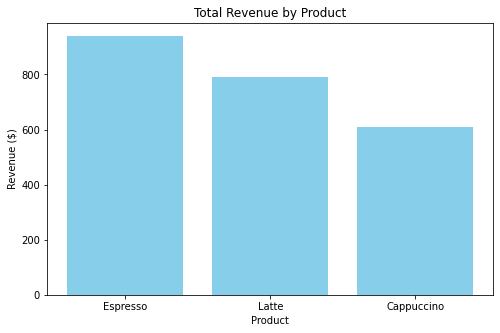

In [11]:
# Creating a Bar chart: Total revenue by product
plt.figure(figsize=(8, 5))
plt.bar(product_revenue['product'], product_revenue['total_revenue'], 
        color='skyblue')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue ($)')
plt.show()

#### The horizontal layout makes it easy to compare across products. I used viridis for a clean and readable color scheme.

## 2. Average Daily Revenue by Day of Week

### Next, I wanted to see if there were revenue patterns across the week. I used a line plot to track the average revenue per day (Monday through Sunday).

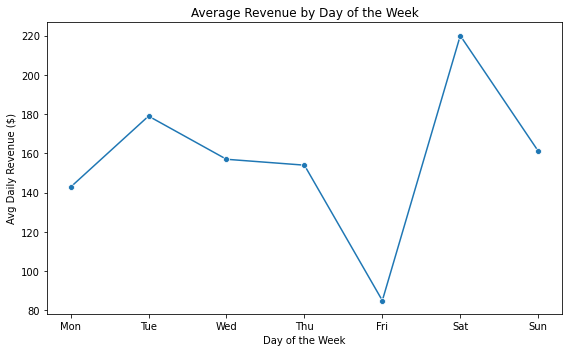

In [12]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_trends['day_name'] = day_trends['day_of_week'].map(lambda x: day_names[x])

plt.figure(figsize=(8, 5))
sns.lineplot(data=day_trends, x='day_name', y='avg_daily_revenue', marker='o')
plt.title('Average Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Avg Daily Revenue ($)')
plt.tight_layout()
plt.show()

# **Stage 5**: Insights Uncovered and Recommendations
---

After analyzing the data and visualizing the trends, here are the main takeaways from this project:

###  Revenue by Product

### **Finding (Values in $):**  
Espresso is the top-performing product, bringing in the highest total revenue at **940**. It's followed by Latte at **792** and then Cappuccino at **608**.

### **Implication:**  
The shop should make sure to always keep Espresso well-stocked and available. Meanwhile, it could be worth running promotions or bundle deals to give Latte and Cappuccino sales a little push.

---

### Day-of-Week Revenue Trends

### **Finding (Values in $):**  
**Saturdays** stand out as the best day, averaging **220** in daily revenue. **Tuesdays** also perform well at **179**. On the flip side, Fridays are the weakest, with just **85** on average.

### **Implication:**  
It might make sense to increase staffing and inventory on Saturdays and Tuesdays to handle demand. For Fridays, offering special discounts, happy hour deals, or themed events could help bring in more customers.